In [ ]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Paso 6: Medidas de localización
---

In [ ]:
df = pl.read_parquet('endireh_2021_clean.parquet')

print(f"Dimensiones de la base: {df.shape}")


resumen = df.select([

    pl.col("edad_primer_union").mean().alias("media_edad"),
    pl.col("edad_primer_union").median().alias("mediana_edad"),

    pl.col("num_hijos").mean().alias("media_num_hijos"),
    pl.col("num_hijos").median().alias("mediana_num_hijos"),

    pl.col("edad_primer_union").quantile(0.25).alias("Q1_edad"),
    pl.col("edad_primer_union").quantile(0.75).alias("Q3_edad"),
    pl.col("edad_primer_union").mode().alias("moda_edad"),
    pl.col("nivel_escolaridad").mode().alias("moda_escolaridad"),
    pl.col("estado_civil_desc").mode().alias("moda_estado_civil"),
    pl.col("nom_entidad").mode().alias("moda_entidad"),
])
print(resumen)

# Media ponderada por el factor de expansion

df_clean = df.drop_nulls(subset=["edad_primer_union", "num_hijos", "factor_expansion"])
edad = df_clean["edad_primer_union"].to_numpy()
num_hijos = df_clean["num_hijos"].to_numpy()
pesos = df_clean["factor_expansion"].to_numpy()

media_ponderada_edad = np.average(edad, weights=pesos)
media_ponderada_num_hijos = np.average(num_hijos, weights=pesos)

print(f"Media de edad ponderada por factor de expansion: {media_ponderada_edad:.2f}")
print(f"Media de num_hijos ponderada por factor de expansion: {media_ponderada_num_hijos:.2f}")

Dimensiones de la base: (105296, 26)
shape: (1, 10)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ media_eda ┆ mediana_e ┆ media_num ┆ mediana_n ┆ … ┆ moda_edad ┆ moda_esco ┆ moda_esta ┆ moda_ent │
│ d         ┆ dad       ┆ _hijos    ┆ um_hijos  ┆   ┆ ---       ┆ laridad   ┆ do_civil  ┆ idad     │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ i64       ┆ ---       ┆ ---       ┆ ---      │
│ f64       ┆ f64       ┆ f64       ┆ f64       ┆   ┆           ┆ cat       ┆ cat       ┆ cat      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 21.606927 ┆ 21.0      ┆ 2.605759  ┆ 3.0       ┆ … ┆ 21        ┆ a1        ┆ casada    ┆ tlaxcala │
└───────────┴───────────┴───────────┴───────────┴───┴───────────┴───────────┴───────────┴──────────┘
Media de edad ponderada por factor de expansion: 21.60
Media de num_hijos ponderada por factor de expansion: 2.61


## Paso 7: Medidad de Variabilidad.
---

In [ ]:

variabilidad = df.select([
    pl.col("edad_primer_union").std().alias("desviacion_estandar_edad"),
    pl.col("edad_primer_union").var().alias("var_edad"),
    (pl.col("edad_primer_union").quantile(0.75) - pl.col("edad_primer_union").quantile(0.25)).alias("IQR_edad")
  ,
    pl.col("num_hijos").std().alias("desviacion_estandar_num_hijos"),
    pl.col("num_hijos").var().alias("var_num_hijos"),
    (pl.col("num_hijos").quantile(0.75) - pl.col("num_hijos").quantile(0.25)).alias("IQR_num_hijos")
])
print(variabilidad)


cv_por_grupo = df_clean.group_by("sufrio_violencia_pareja").agg([
    pl.col("edad_primer_union").mean().alias("media_edad"),
    pl.col("edad_primer_union").std().alias("desviacion_estandar_edad"),
    ((pl.col("edad_primer_union").std() / pl.col("edad_primer_union").mean()) * 100).alias("CV_porcentaje_edad"),

    pl.col("num_hijos").mean().alias("media_hijos"),
    pl.col("num_hijos").std().alias("desviacion_estandar_hijos"),
    ((pl.col("num_hijos").std() / pl.col("num_hijos").mean()) * 100).alias("CV_porcentaje_hijos")
])
print(cv_por_grupo)

shape: (1, 6)
┌─────────────────────┬───────────┬──────────┬─────────────────────┬───────────────┬───────────────┐
│ desviacion_estandar ┆ var_edad  ┆ IQR_edad ┆ desviacion_estandar ┆ var_num_hijos ┆ IQR_num_hijos │
│ _edad               ┆ ---       ┆ ---      ┆ _num_hijos          ┆ ---           ┆ ---           │
│ ---                 ┆ f64       ┆ f64      ┆ ---                 ┆ f64           ┆ f64           │
│ f64                 ┆           ┆          ┆ f64                 ┆               ┆               │
╞═════════════════════╪═══════════╪══════════╪═════════════════════╪═══════════════╪═══════════════╡
│ 6.554               ┆ 42.954918 ┆ 0.0      ┆ 1.091477            ┆ 1.191322      ┆ 2.0           │
└─────────────────────┴───────────┴──────────┴─────────────────────┴───────────────┴───────────────┘
shape: (2, 7)
┌──────────────┬────────────┬──────────────┬─────────────┬─────────────┬─────────────┬─────────────┐
│ sufrio_viole ┆ media_edad ┆ desviacion_e ┆ CV_porcenta ┆ medi

## Visualización de resultados EDA.
---

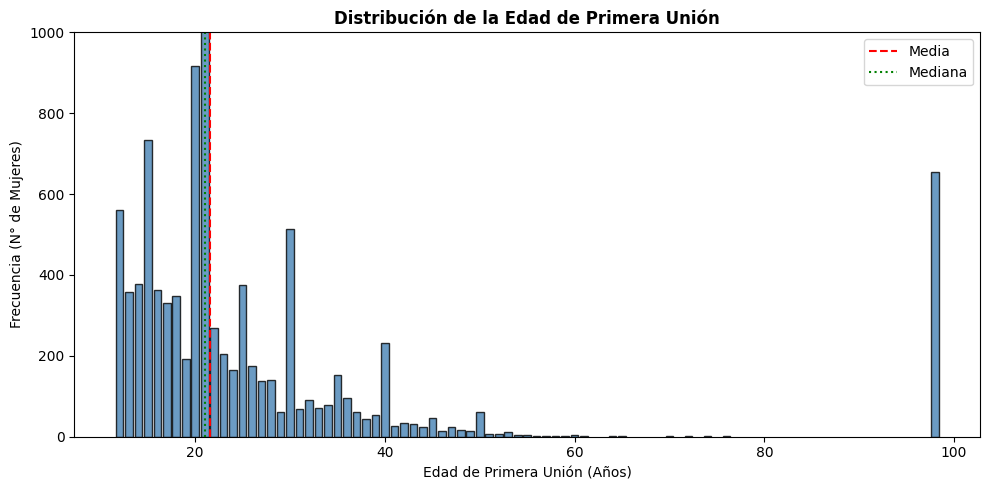

In [ ]:
plt.figure(figsize=(10, 5))
edad_counts = (
    df_clean.filter(pl.col("edad_primer_union").is_not_null())
    .group_by("edad_primer_union")
    .agg(pl.len().alias("frecuencia"))
    .sort("edad_primer_union")
)

plt.bar(
    edad_counts["edad_primer_union"].to_numpy(),
    edad_counts["frecuencia"].to_numpy(),
    color="steelblue",
    edgecolor="black",
    alpha=0.8
)

plt.axvline(x=df['edad_primer_union'].mean(), color="red", linestyle="--", label="Media")
plt.axvline(x=df["edad_primer_union"].median(), color="green", linestyle=":", label="Mediana")
plt.title("Distribución de la Edad de Primera Unión", fontweight="bold")
plt.xlabel("Edad de Primera Unión (Años)")
plt.ylim(0, 1000)
plt.ylabel("Frecuencia (N° de Mujeres)")
plt.tight_layout()
plt.legend()
plt.savefig("edad_primer_union.png")
plt.show()

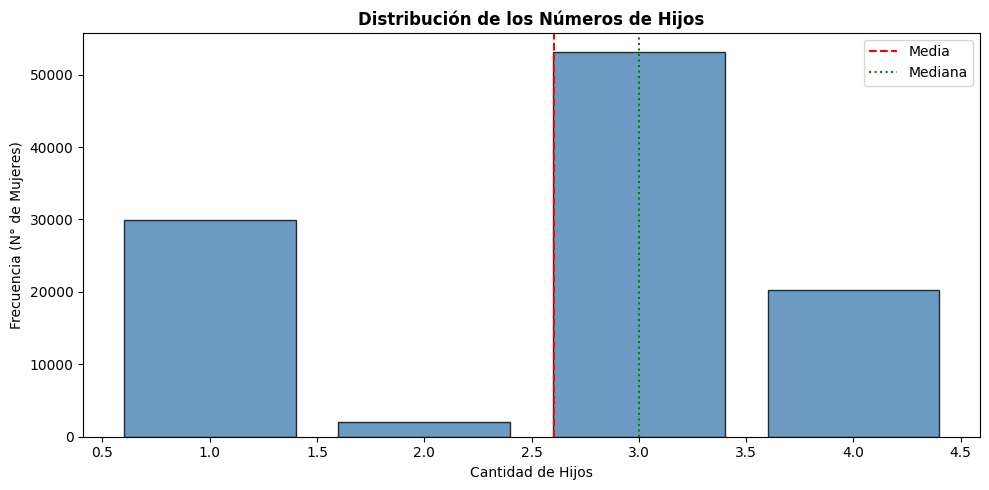

In [ ]:
plt.figure(figsize=(10, 5))
num_hijos_counts = (
    df_clean.filter(pl.col("num_hijos").is_not_null())
    .group_by("num_hijos")
    .agg(pl.len().alias("frecuencia"))
    .sort("num_hijos")
)

plt.bar(
    num_hijos_counts["num_hijos"].to_numpy(),
    num_hijos_counts["frecuencia"].to_numpy(),
    color="steelblue",
    edgecolor="black",
    alpha=0.8
)
plt.axvline(x=df["num_hijos"].mean(), color="red", linestyle="--", label="Media")
plt.axvline(x=df["num_hijos"].median(), color="green", linestyle=":", label="Mediana")
plt.title("Distribución de los Números de Hijos", fontweight="bold")
plt.xlabel("Cantidad de Hijos")
plt.ylabel("Frecuencia (N° de Mujeres)")
plt.tight_layout()
plt.legend()
plt.savefig("num_hijos.png")
plt.show()

/tmp/ipykernel_2803/718658592.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


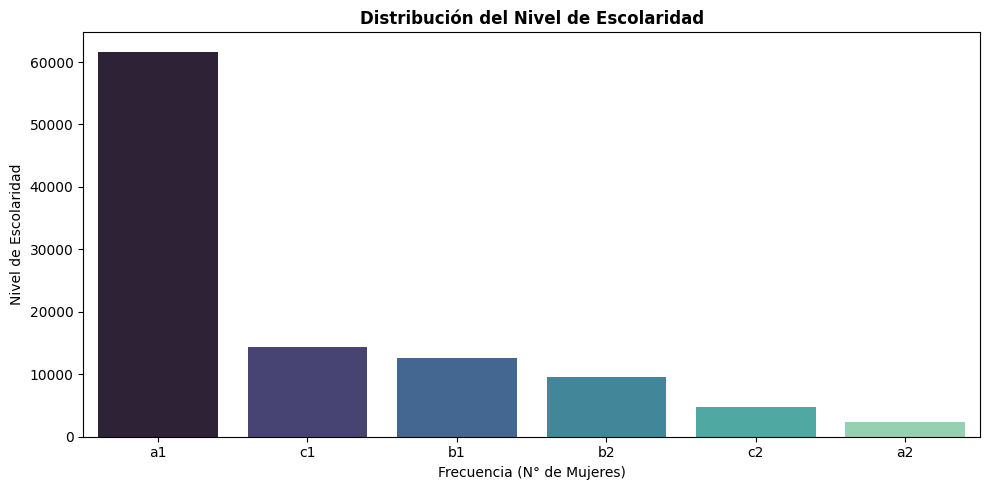

In [ ]:
plt.figure(figsize=(10, 5))
escolaridad_counts = (
    df.filter(pl.col("nivel_escolaridad").is_not_null())
    .group_by("nivel_escolaridad")
    .agg(pl.len().alias("frecuencia"))
    .sort("frecuencia", descending=True)
)

sns.barplot(
    y=escolaridad_counts["frecuencia"].to_numpy(),
    x=escolaridad_counts["nivel_escolaridad"].to_numpy(),
    palette="mako"
)
plt.title("Distribución del Nivel de Escolaridad", fontweight="bold")
plt.xlabel("Frecuencia (N° de Mujeres)")
plt.ylabel("Nivel de Escolaridad")
plt.tight_layout()
plt.savefig("nivel_escolaridad.png")
plt.show()

/tmp/ipykernel_2803/4105329540.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


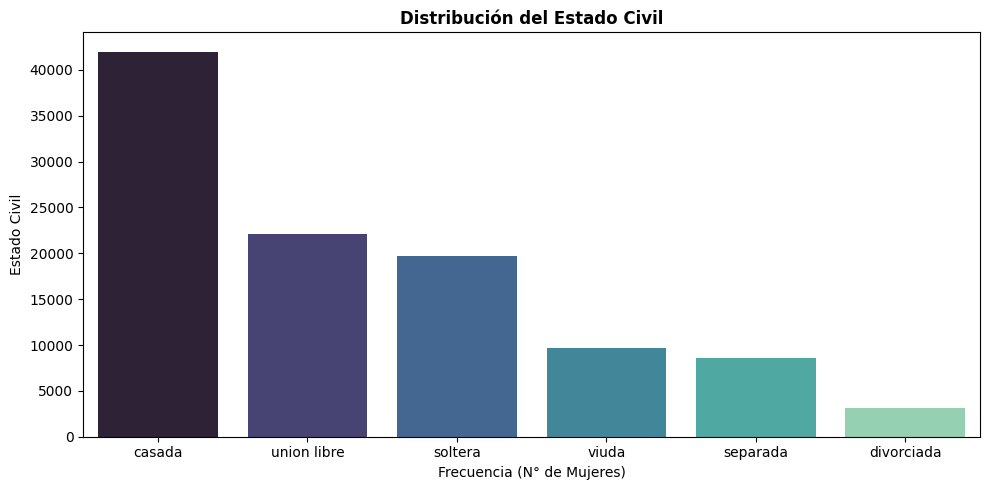

In [ ]:
plt.figure(figsize=(10, 5))
estado_counts = (
    df.filter(pl.col("estado_civil_desc").is_not_null())
    .group_by("estado_civil_desc")
    .agg(pl.len().alias("frecuencia"))
    .sort("frecuencia", descending=True)
)

sns.barplot(
    y=estado_counts["frecuencia"].to_numpy(),
    x=estado_counts["estado_civil_desc"].to_numpy(),
    palette="mako"
)
plt.title("Distribución del Estado Civil", fontweight="bold")
plt.xlabel("Frecuencia (N° de Mujeres)")
plt.ylabel("Estado Civil")
plt.tight_layout()
plt.savefig("estado_civil.png")
plt.show()

/tmp/ipykernel_2803/1068365039.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


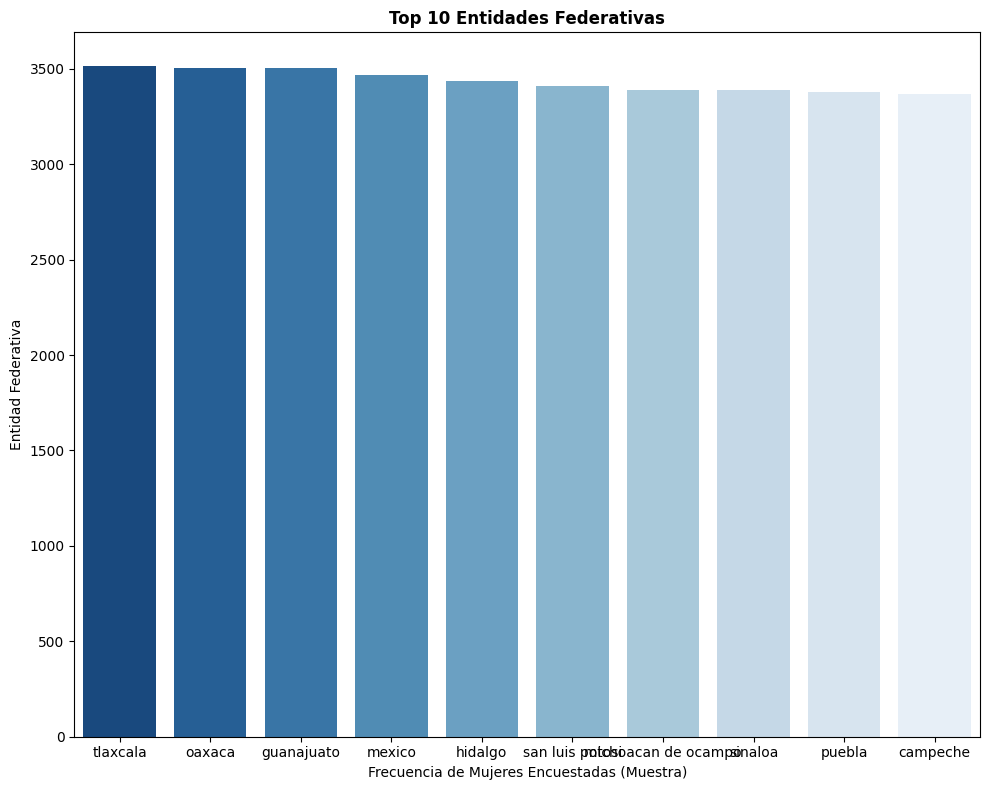

In [ ]:
plt.figure(figsize=(10, 8))
entidad_counts = (
    df.filter(pl.col("nom_entidad").is_not_null())
    .group_by("nom_entidad")
    .agg(pl.len().alias("frecuencia"))
    .sort("frecuencia", descending=True)
    .head(10)
)

sns.barplot(
    y=entidad_counts["frecuencia"].to_numpy(),
    x=entidad_counts["nom_entidad"].to_numpy(),
    palette="Blues_r"
)
plt.title("Top 10 Entidades Federativas", fontweight="bold")
plt.xlabel("Frecuencia de Mujeres Encuestadas (Muestra)")
plt.ylabel("Entidad Federativa")
plt.tight_layout()
plt.savefig("entidad_federativa.png")
plt.show()

/tmp/ipykernel_2803/1854048670.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


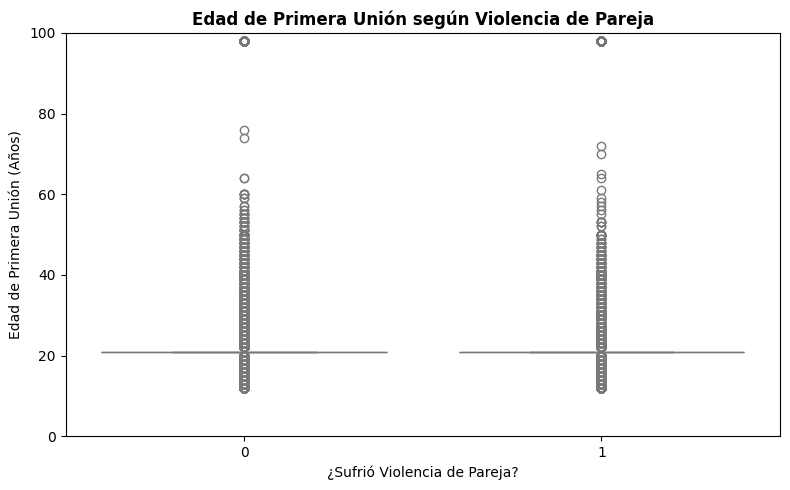

In [ ]:
df_box1 = df_clean.filter(
    pl.col("edad_primer_union").is_not_null() & pl.col("sufrio_violencia_pareja").is_not_null()
).to_pandas()

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_box1,
    x="sufrio_violencia_pareja",
    y="edad_primer_union",
    palette="coolwarm"
)
plt.title("Edad de Primera Unión según Violencia de Pareja", fontweight="bold")
plt.xlabel("¿Sufrió Violencia de Pareja?")
plt.ylabel("Edad de Primera Unión (Años)")
plt.ylim(0,100)
plt.tight_layout()
plt.savefig("violencia_pareja.png")
plt.show()

/tmp/ipykernel_2803/3619733289.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


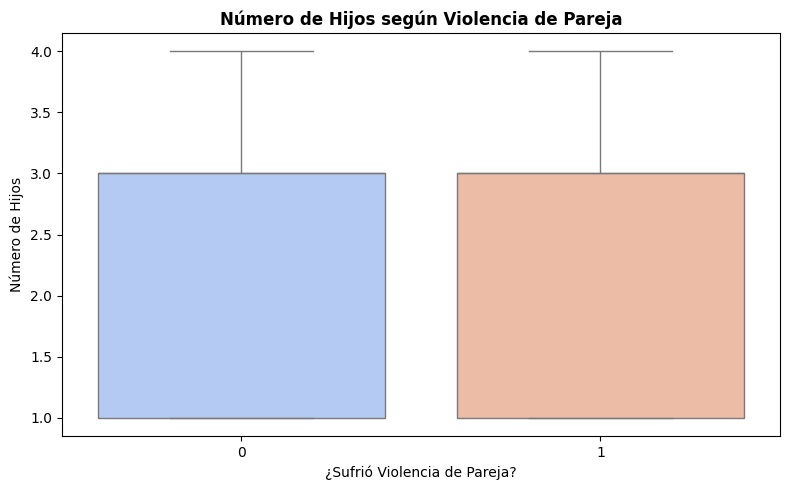

In [ ]:
df_box2 = df.filter(
    pl.col("num_hijos").is_not_null() & pl.col("sufrio_violencia_pareja").is_not_null()
).to_pandas()

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_box2,
    x="sufrio_violencia_pareja",
    y="num_hijos",
    palette="coolwarm"
)
plt.title("Número de Hijos según Violencia de Pareja", fontweight="bold")
plt.xlabel("¿Sufrió Violencia de Pareja?")
plt.ylabel("Número de Hijos")
plt.tight_layout()
plt.savefig("violencia_pareja_hijos.png")
plt.show()

/tmp/ipykernel_2803/3667689991.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


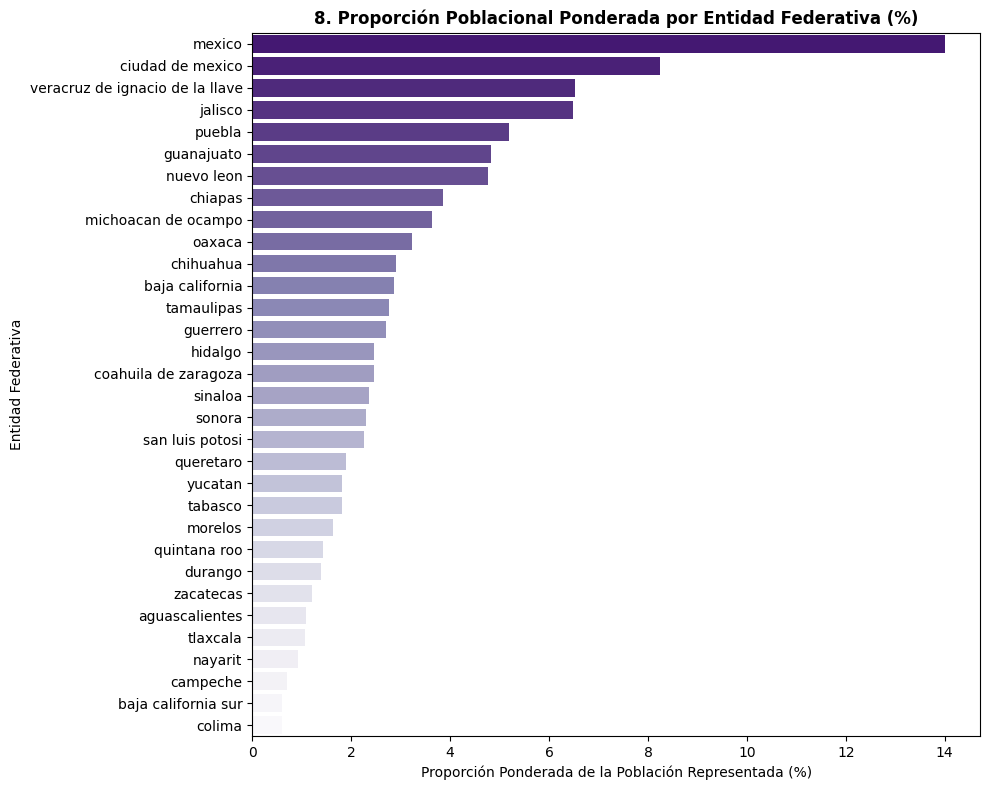

In [ ]:
total_poblacion = df.select(pl.col("factor_expansion").sum()).item()

ent_ponderada = (
    df.filter(pl.col("nom_entidad").is_not_null())
    .group_by("nom_entidad")
    .agg(((pl.col("factor_expansion").sum() / total_poblacion) * 100).alias("proporcion_ponderada"))
    .sort("proporcion_ponderada", descending=True)
)

plt.figure(figsize=(10, 8))
sns.barplot(
    x=ent_ponderada["proporcion_ponderada"].to_numpy(),
    y=ent_ponderada["nom_entidad"].to_numpy(),
    palette="Purples_r"
)
plt.title("8. Proporción Poblacional Ponderada por Entidad Federativa (%)", fontweight="bold")
plt.xlabel("Proporción Ponderada de la Población Representada (%)")
plt.ylabel("Entidad Federativa")
plt.tight_layout()
plt.savefig("proporcion_ponderada_entidad.png")
plt.show()